# Phase 6 — Results and figures (`paper/PLAN.md`)

Builds the figures and tables `paper/paper.md` will cite, from
`results/metrics.csv` (phase 5), `results/rule_based_ranking.csv`
(phase 3), and `results/llm_runs/` (phase 4). No network, no LLM key
needed. Outputs are written to `results/figures/`.

## Setup

In [1]:
import json
import math
import statistics
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap

RESULTS = Path("../results")
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed")

# Palette (validated categorical pair + sequential blue ramp - see the
# dataviz skill's references/palette.md; slots 1/2 are the adjacent-safe
# default pair, already validated, not re-picked here).
COLOR_RULE_BASED = "#2a78d6"   # categorical slot 1 (blue)
COLOR_LLM = "#eb6834"          # categorical slot 2 (orange)
COLOR_INK = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_GRID = "#e1e0d9"
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLOR_GRID,
    "axes.labelcolor": COLOR_INK,
    "text.color": COLOR_INK,
    "xtick.color": COLOR_INK_SECONDARY,
    "ytick.color": COLOR_INK_SECONDARY,
    "font.size": 10,
})

## Load phase 3/4/5 outputs

In [2]:
metrics_df = pd.read_csv(RESULTS / "metrics.csv")
rb_ranking_df = pd.read_csv(RESULTS / "rule_based_ranking.csv")
llm_run_files = sorted((RESULTS / "llm_runs").glob("run_*.json"))
llm_runs = [json.loads(f.read_text()) for f in llm_run_files]
with open(PROCESSED / "districts.geojson") as fh:
    districts_geojson = json.load(fh)

print(f"metrics.csv: {len(metrics_df)} rows")
print(f"rule_based_ranking.csv: {len(rb_ranking_df)} districts")
print(f"llm_runs: {len(llm_runs)} runs")
print(f"districts.geojson: {len(districts_geojson['features'])} district polygons")

metrics.csv: 2 rows
rule_based_ranking.csv: 23 districts
llm_runs: 20 runs
districts.geojson: 23 district polygons


## Table 1 — the `paper/comparison_metric.md` reporting table

In [3]:
def fmt_pct(x):
    return f"{x:.1%}" if pd.notna(x) else "-"

def fmt_rho(mean, sd):
    return f"{mean:.4f} +/- {sd:.4f}" if pd.notna(mean) else "-"

def fmt_latency(median, lo, hi):
    if pd.isna(median):
        return "-"
    return f"{median:.1f}s (IQR {lo:.1f}-{hi:.1f}s)"

def df_to_markdown(df: pd.DataFrame) -> str:
    """Minimal pipe-table writer - avoids depending on the optional
    'tabulate' package (not in requirements.txt; pandas' own
    DataFrame.to_markdown() needs it and raises ImportError without it)."""
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)

table1_rows = []
for _, row in metrics_df.iterrows():
    table1_rows.append({
        "Arm": "Rule-based" if row["arm"] == "rule_based" else "LLM",
        "N": int(row["n_runs"]),
        "PAR": f"{row['par']:.3f}",
        "Weight sd (metro/schools/parks)": f"{row['weight_sd_metro']:.3f} / {row['weight_sd_schools']:.3f} / {row['weight_sd_parks']:.3f}",
        "Rank Stability (rho, mean +/- sd)": fmt_rho(row["rank_stability_mean"], row["rank_stability_sd"]),
        "rho vs. rule-based": f"{row['rho_vs_rule_based_mean']:.4f}",
        "Success rate": fmt_pct(row["success_rate"]),
        "Median latency": fmt_latency(row["median_latency_s"], row["latency_iqr_low_s"], row["latency_iqr_high_s"]),
    })
table1 = pd.DataFrame(table1_rows)

# Save a paste-ready markdown table for paper/paper.md
table1_md = df_to_markdown(table1)
(FIGURES / "table1_reporting.md").write_text(table1_md + "\n")
print(f"wrote {(FIGURES / 'table1_reporting.md').resolve()}")
print()
table1

wrote /home/araz/Projects/Career/smart-spatial-vienna-accessibility/results/figures/table1_reporting.md



          Arm   N    PAR Weight sd (metro/schools/parks) Rank Stability (rho, mean +/- sd) rho vs. rule-based Success rate          Median latency
0  Rule-based   5  1.000           0.000 / 0.000 / 0.000                 1.0000 +/- 0.0000             1.0000       100.0%                       -
1         LLM  20  1.000           0.000 / 0.000 / 0.000                 1.0000 +/- 0.0000             0.9990       100.0%  20.0s (IQR 18.8-21.7s)

## Figure 1 — District accessibility, rule-based vs. LLM arm

All 20 LLM runs are numerically identical (phase 4 Round 10 / phase 5),
so `run_00` stands in for "the LLM arm" here without loss of information.

wrote /home/araz/Projects/Career/smart-spatial-vienna-accessibility/results/figures/fig1_choropleth.png


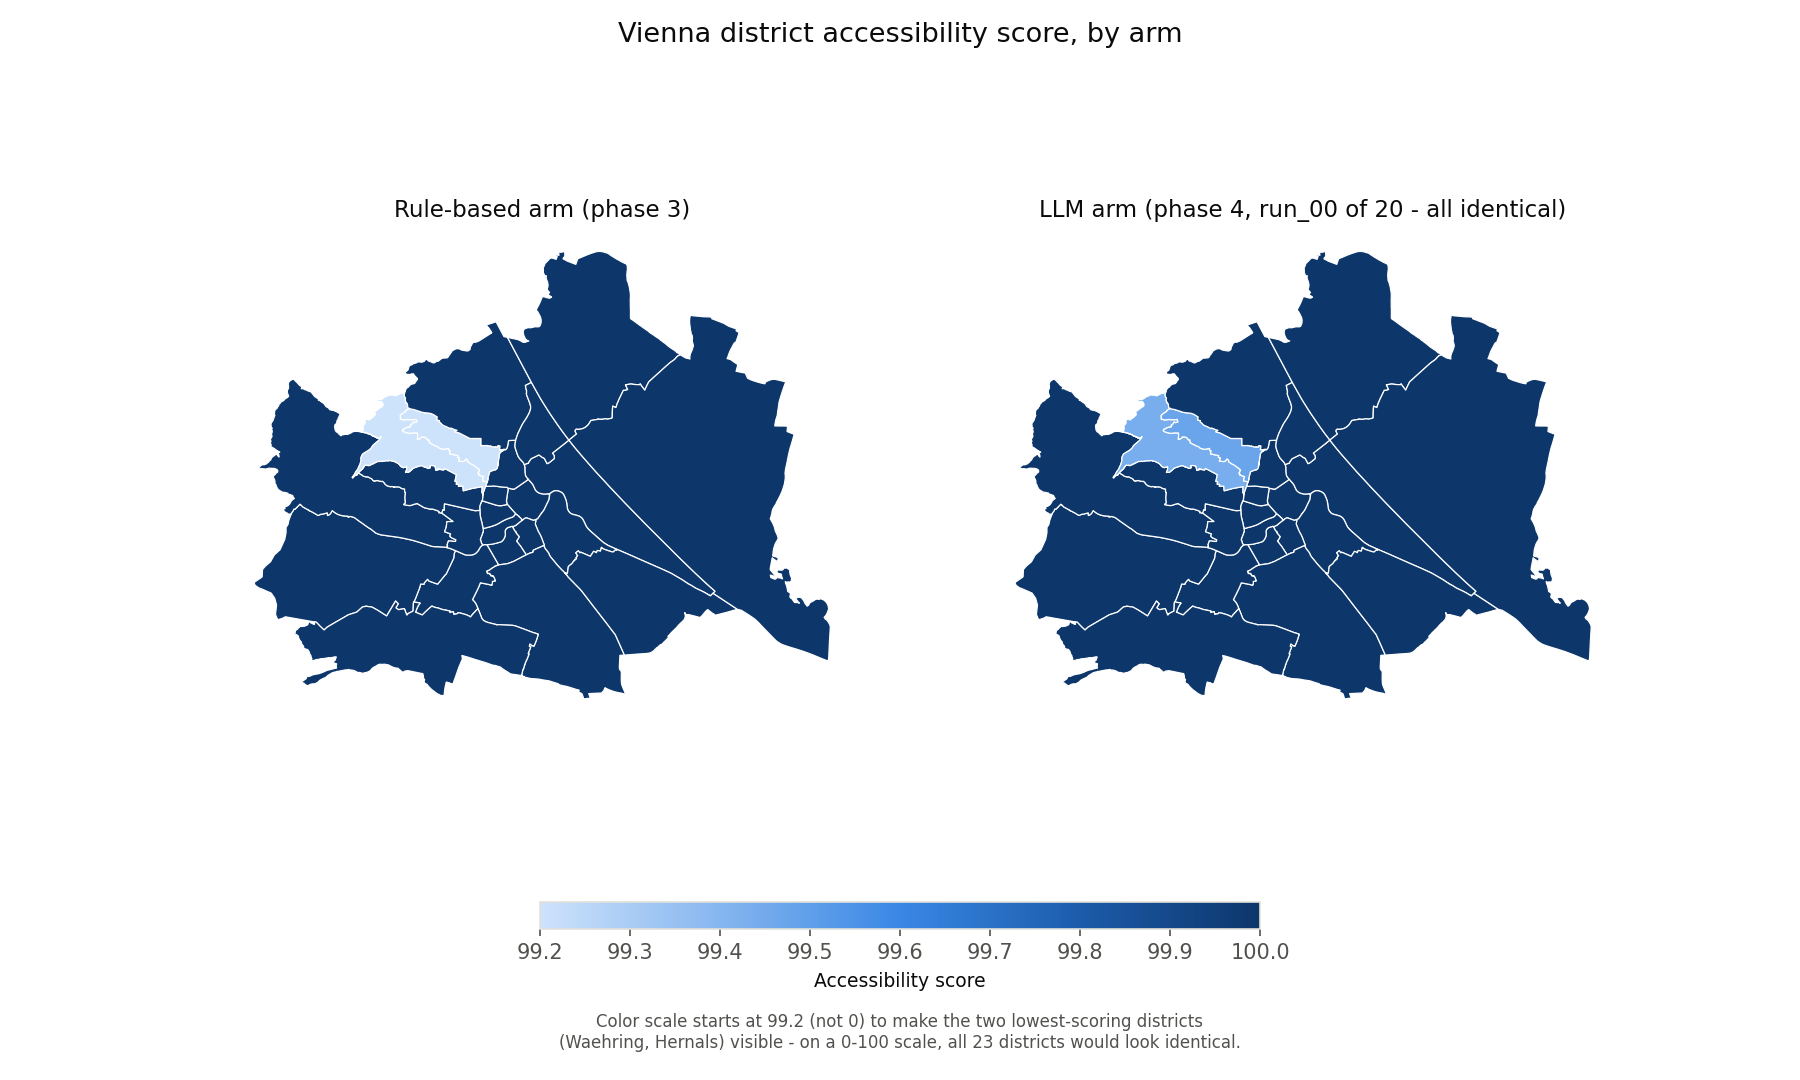

In [4]:
def polygon_patches(geojson, value_by_name):
    patches, values = [], []
    for feat in geojson["features"]:
        name = feat["properties"]["name"]
        coords = feat["geometry"]["coordinates"][0]  # exterior ring; all districts are simple Polygons
        patches.append(MplPolygon(coords, closed=True))
        values.append(value_by_name[name])
    return patches, np.array(values)

rb_scores = dict(zip(rb_ranking_df["name"], rb_ranking_df["accessibility_score"]))
llm_scores = {d["name"]: d["score"] for d in llm_runs[0]["ranking"]}

# Vienna is at ~48.2N - 1 degree longitude is shorter than 1 degree
# latitude there; correct the aspect ratio rather than let the map look
# horizontally stretched.
lat0 = districts_geojson["features"][0]["geometry"]["coordinates"][0][0][1]
aspect = 1.0 / math.cos(math.radians(lat0))

vmin = min(min(rb_scores.values()), min(llm_scores.values()))
vmax = 100.0
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 7.2))
for ax, scores, title in [
    (axes[0], rb_scores, "Rule-based arm (phase 3)"),
    (axes[1], llm_scores, f"LLM arm (phase 4, run_00 of {len(llm_runs)} - all identical)"),
]:
    patches, values = polygon_patches(districts_geojson, scores)
    coll = PatchCollection(patches, cmap=SEQUENTIAL_BLUE, norm=norm, edgecolor="white", linewidth=0.6)
    coll.set_array(values)
    ax.add_collection(coll)
    ax.set_aspect(aspect)
    ax.autoscale_view()
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.subplots_adjust(bottom=0.22, top=0.90)
cbar_ax = fig.add_axes([0.3, 0.14, 0.4, 0.025])
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=SEQUENTIAL_BLUE), cax=cbar_ax, orientation="horizontal")
cbar.set_label("Accessibility score", fontsize=9)
fig.suptitle("Vienna district accessibility score, by arm", fontsize=13, y=0.98)
fig.text(0.5, 0.03,
         f"Color scale starts at {vmin:.1f} (not 0) to make the two lowest-scoring districts\n"
         "(Waehring, Hernals) visible - on a 0-100 scale, all 23 districts would look identical.",
         ha="center", fontsize=8, color="#52514e")
fig.savefig(FIGURES / "fig1_choropleth.png", dpi=150)
plt.show()
print(f"wrote {(FIGURES / 'fig1_choropleth.png').resolve()}")

## Figure 2 — Layer 2: rule-based's given weighting vs. the LLM arm's invented flat default

The raw query never gives the LLM weight/`max_distance` numbers (phase 4
design) - this shows what it invents instead, against what the
rule-based arm was simply given.

wrote /home/araz/Projects/Career/smart-spatial-vienna-accessibility/results/figures/fig2_weights.png
metro    rule-based weight=3.0  LLM mean weight=1.000 (sd=0.000)
schools  rule-based weight=2.0  LLM mean weight=1.000 (sd=0.000)
parks    rule-based weight=1.0  LLM mean weight=1.000 (sd=0.000)


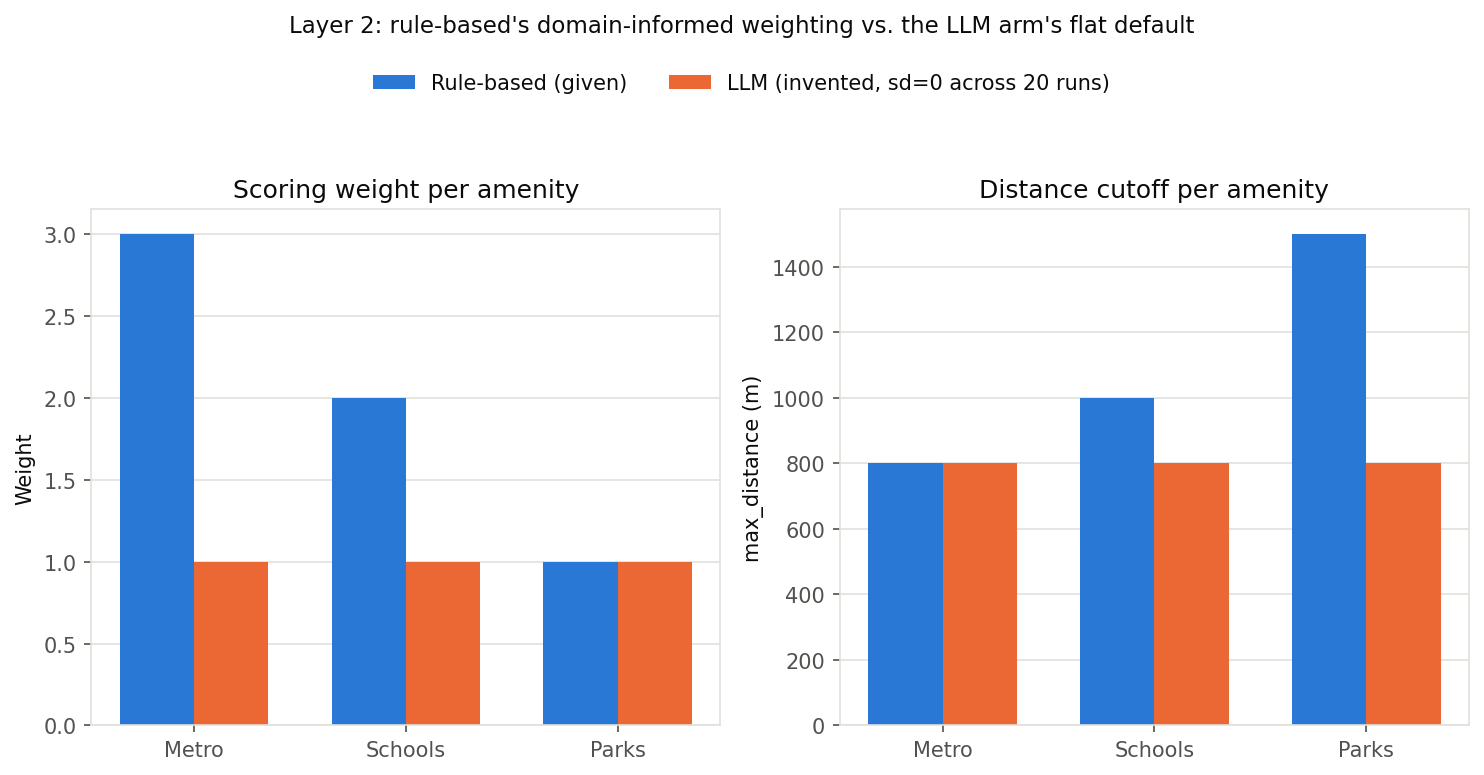

In [5]:
rb_amenities = {a["ref"]: a for a in json.load(open(RESULTS / "rule_based_query_spec.json"))["amenities"]}
llm_field_to_amenity = {"distance_to_metro": "metro", "distance_to_schools": "schools", "distance_to_parks": "parks"}

def extract_llm_factor_values(field_key):
    from re import match as _m
    def parse_op(s):
        mobj = _m(r"OperationSpec\((.*)\)$", s)
        ns = {}
        exec(f"d = dict({mobj.group(1)})", {}, ns)
        return ns["d"]
    vals = {"weight": [], "max_distance": []}
    for run in llm_runs:
        ops = [parse_op(s) for s in run["operation_sequence"]]
        score_op = next(o for o in ops if o["op"] == "score_features")
        params = score_op["params"]
        factors = params["scoring_spec"]["factors"] if "scoring_spec" in params else params["factors"]
        f = next(f for f in factors if f["field"] == field_key)
        vals["weight"].append(float(f["weight"]))
        vals["max_distance"].append(float(f.get("max_distance", f.get("max_distance_m"))))
    return vals

amenities_order = ["metro", "schools", "parks"]
llm_by_amenity = {a: extract_llm_factor_values(k) for k, a in llm_field_to_amenity.items()}

fig, (ax_w, ax_d) = plt.subplots(1, 2, figsize=(10, 4.5))
x = np.arange(len(amenities_order))
width = 0.35

rb_weights = [rb_amenities[a]["weight"] for a in amenities_order]
llm_weights = [statistics.mean(llm_by_amenity[a]["weight"]) for a in amenities_order]
ax_w.bar(x - width/2, rb_weights, width, label="Rule-based (given)", color=COLOR_RULE_BASED)
ax_w.bar(x + width/2, llm_weights, width, label="LLM (invented, sd=0 across 20 runs)", color=COLOR_LLM)
ax_w.set_xticks(x); ax_w.set_xticklabels([a.capitalize() for a in amenities_order])
ax_w.set_ylabel("Weight")
ax_w.set_title("Scoring weight per amenity")
ax_w.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax_w.set_axisbelow(True)

rb_maxdist = [rb_amenities[a]["max_distance_m"] for a in amenities_order]
llm_maxdist = [statistics.mean(llm_by_amenity[a]["max_distance"]) for a in amenities_order]
ax_d.bar(x - width/2, rb_maxdist, width, label="Rule-based (given)", color=COLOR_RULE_BASED)
ax_d.bar(x + width/2, llm_maxdist, width, label="LLM (invented, sd=0 across 20 runs)", color=COLOR_LLM)
ax_d.set_xticks(x); ax_d.set_xticklabels([a.capitalize() for a in amenities_order])
ax_d.set_ylabel("max_distance (m)")
ax_d.set_title("Distance cutoff per amenity")
ax_d.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax_d.set_axisbelow(True)

handles, labels = ax_w.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
fig.suptitle("Layer 2: rule-based's domain-informed weighting vs. the LLM arm's flat default", y=1.14, fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "fig2_weights.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {(FIGURES / 'fig2_weights.png').resolve()}")

for a in amenities_order:
    llm_w = llm_by_amenity[a]["weight"]
    print(f"{a:8s} rule-based weight={rb_amenities[a]['weight']}  LLM mean weight={statistics.mean(llm_w):.3f} (sd={statistics.pstdev(llm_w):.3f})")

## Figure 3 — LLM arm latency distribution

wrote /home/araz/Projects/Career/smart-spatial-vienna-accessibility/results/figures/fig3_latency.png
min=17.56s max=24.99s median=20.01s Q1=18.78s Q3=21.70s


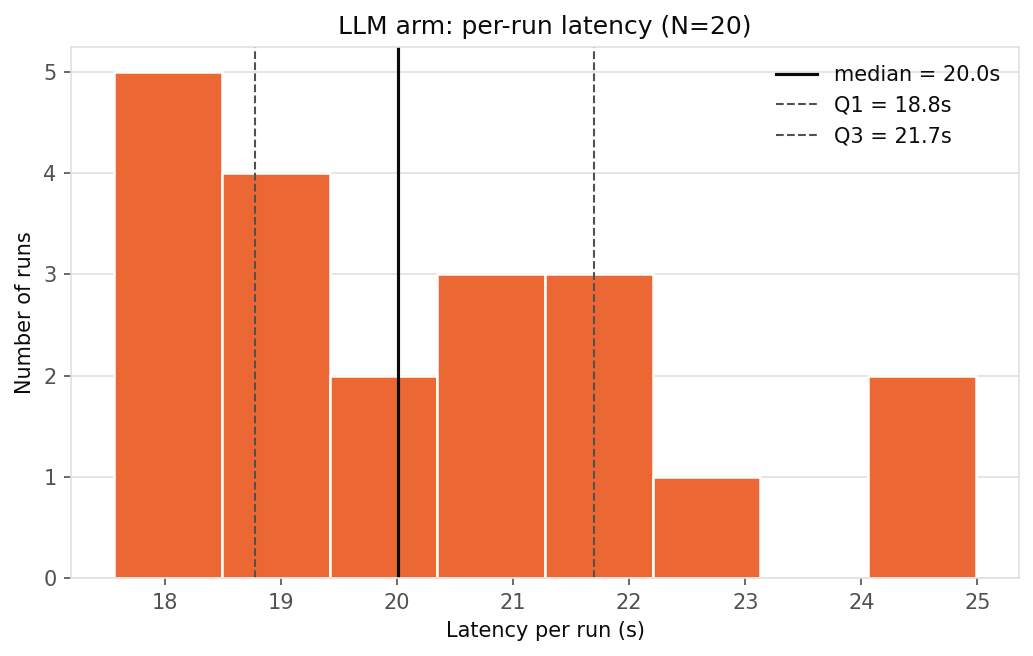

In [6]:
latencies = [r["latency_s"] for r in llm_runs]
median = statistics.median(latencies)
sorted_lat = sorted(latencies)
n = len(sorted_lat)
q1 = sorted_lat[n // 4]
q3 = sorted_lat[(3 * n) // 4]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(latencies, bins=8, color=COLOR_LLM, edgecolor="white", linewidth=1.2)
ax.axvline(median, color=COLOR_INK, linewidth=1.5, linestyle="-", label=f"median = {median:.1f}s")
ax.axvline(q1, color=COLOR_INK_SECONDARY, linewidth=1, linestyle="--", label=f"Q1 = {q1:.1f}s")
ax.axvline(q3, color=COLOR_INK_SECONDARY, linewidth=1, linestyle="--", label=f"Q3 = {q3:.1f}s")
ax.set_xlabel("Latency per run (s)")
ax.set_ylabel("Number of runs")
ax.set_title("LLM arm: per-run latency (N=20)")
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "fig3_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {(FIGURES / 'fig3_latency.png').resolve()}")
print(f"min={min(latencies):.2f}s max={max(latencies):.2f}s median={median:.2f}s Q1={q1:.2f}s Q3={q3:.2f}s")

## Final checks

In [7]:
assert (FIGURES / "table1_reporting.md").exists()
assert (FIGURES / "fig1_choropleth.png").exists()
assert (FIGURES / "fig2_weights.png").exists()
assert (FIGURES / "fig3_latency.png").exists()
for f in ["table1_reporting.md", "fig1_choropleth.png", "fig2_weights.png", "fig3_latency.png"]:
    size = (FIGURES / f).stat().st_size
    assert size > 0, f"{f} is empty"
    print(f"{f}: {size} bytes")
print()
print("all checks passed")

table1_reporting.md: 376 bytes
fig1_choropleth.png: 181922 bytes
fig2_weights.png: 70926 bytes
fig3_latency.png: 38502 bytes

all checks passed


## Next: phase 7

Paper writing (`paper/paper.md`). All figures/tables now exist in
`results/figures/` and can be cited directly; `paper/PLAN.md`'s
"Findings to fold into the paper's discussion" section already has the
prose for the ceiling-effect, Layer 2 weighting, and rounding-tie
findings these figures illustrate.